In [1]:
!pip install transformers
!pip install torch
!pip install pillow
!pip install matplotlib

In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
import matplotlib.pyplot as plt

In [3]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

(np.float64(-0.5), np.float64(7374.5), np.float64(4918.5), np.float64(-0.5))

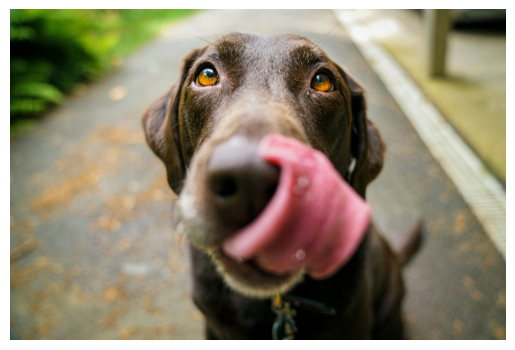

In [4]:
url = "https://images.unsplash.com/photo-1518717758536-85ae29035b6d"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

plt.imshow(image)
plt.axis("off")

In [5]:
inputs = processor(image, return_tensors="pt")

In [6]:
output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print("Generated Caption:")
print(caption)

Generated Caption:
a dog with its tongue out


In [7]:
output = model.generate(
    **inputs,
    max_length=30,
    num_beams=5
)

caption = processor.decode(output[0], skip_special_tokens=True)

print(caption)

a close up of a dog with its tongue sticking out


In [8]:

image_urls = [
"https://images.unsplash.com/photo-1518717758536-85ae29035b6d",
"https://images.unsplash.com/photo-1506744038136-46273834b3fb",
"https://images.unsplash.com/photo-1517849845537-4d257902454a"
]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

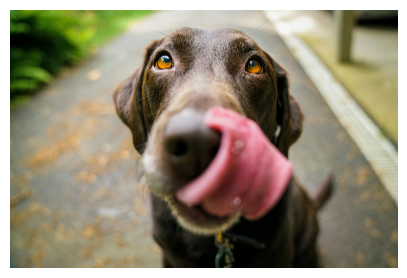

Generated Caption: a dog with its tongue out
--------------------------------------------------


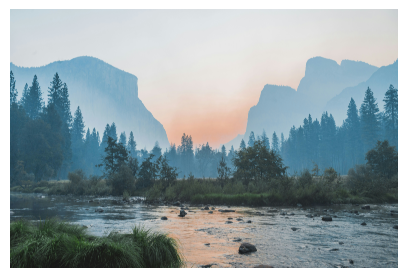

Generated Caption: a river with a mountain in the background
--------------------------------------------------


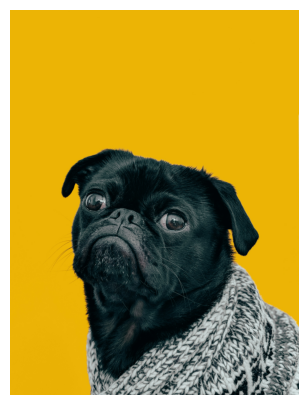

Generated Caption: a black pug dog wearing a scarf
--------------------------------------------------


In [9]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
import matplotlib.pyplot as plt

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

image_urls = [
"https://images.unsplash.com/photo-1518717758536-85ae29035b6d",
"https://images.unsplash.com/photo-1506744038136-46273834b3fb",
"https://images.unsplash.com/photo-1517849845537-4d257902454a"
]

for url in image_urls:

    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

    inputs = processor(image, return_tensors="pt")
    output = model.generate(**inputs)

    caption = processor.decode(output[0], skip_special_tokens=True)

    plt.figure(figsize=(5,5))   # Important
    plt.imshow(image)
    plt.axis("off")
    plt.show()                  # Important

    print("Generated Caption:", caption)
    print("--------------------------------------------------")